# 02 · From Nash to Selten to Harsanyi with Gambit / PyGambit
**COMSCI/ECON 206 · Computational Microeconomics · Autumn 2026**  
**Instructor: Prof. Luyao Zhang**

Build the smallest model, then add only the structure the research question requires.

| Lens | Ask first | Represent | Change interactively |
|---|---|---|---|
| **Nash** | Can either player gain by deviating alone? | Simultaneous payoff matrix | Matrix payoffs in Notebook 01 |
| **Selten** | Is every continuation credible after each observed history? | Sequential tree | Fight, accommodate, and entrant payoffs |
| **Harsanyi** | What type is private, what is believed, and what does each type choose? | Types, prior, and information sets | Prior and both firms' costs |

**Learning loop:** predict → run the baseline → move one control → explain which incentive inequality changed. A tree is only a representation: observed histories support a Selten analysis; private types, priors, and information sets support a Harsanyi analysis.

**Run in Colab:** select CPU, run the setup cell first, then **Runtime → Run all**. PyGambit may compile for several minutes on its first Linux/Colab installation. The saved figures and tables remain readable without running.

[Open in Colab](https://colab.research.google.com/github/sunshineluyao/gt-tools-demos/blob/main/notebooks/gambit_pygambit/02_Gambit_PyGambit_Interactive.ipynb) · [Read-only teaching page](https://github.com/sunshineluyao/gt-tools-demos/blob/main/docs/02_Trees_and_Information_Demo.md)

In [1]:
# PyGambit is the Python interface to Gambit (not the unrelated package "gambit").
# Linux/Colab may build it from source: allow several minutes on the FIRST run.
# Run this cell before class. Subsequent calculations are small CPU-only examples.
import sys
import os
import shutil
import subprocess
from importlib.metadata import version, PackageNotFoundError

required = {"pygambit": "16.7.0", "ipywidgets": "8.1.7"}
for package, wanted in required.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    if installed != wanted:
        build_env = os.environ.copy()
        if package == "pygambit" and sys.platform.startswith("linux"):
            # Explicit GNU tools also work in environments with stale compiler settings.
            for setting, executable in {"CC": "gcc", "CXX": "g++", "AR": "ar", "RANLIB": "ranlib"}.items():
                found = shutil.which(executable)
                if found is None:
                    raise RuntimeError("A C++ build tool is missing. Use Colab or install your system's C++ build tools.")
                build_env[setting] = found
            build_env["LDSHARED"] = build_env["CXX"] + " -shared"
        subprocess.check_call([sys.executable, "-m", "pip", "install", f"{package}=={wanted}"], env=build_env)

print("Python", sys.version.split()[0])
for package in required:
    print(package, version(package))


Python 3.12.14
pygambit 16.7.0
ipywidgets 8.1.7


In [2]:
import pygambit as gb                 # Game trees, information sets and solvers.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from itertools import product
from pathlib import Path
from IPython.display import display, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

EXPORT = Path("game_exports")          # Portable files for the Gambit desktop UI.
EXPORT.mkdir(exist_ok=True)


## 1. Nash: verify mutual best responses

`enumpure_solve` lists pure Nash equilibria; it does not claim to list mixed equilibria.

| Cue | Pseudocode | Check |
|---|---|---|
| 🧩 Input | `G ← game(A,B)` | Two players, at least two strategies each, complete payoffs |
| ⚙️ Enumerate | `E ← pure_nash(G)` | Each profile specifies one action for every player |
| ✓ Verify | `for e in E: test every unilateral deviation` | $u_i(e)\geq u_i(a_i',e_{-i})$ for every player $i$ and action $a_i'$ |
| → Report | `show actions and payoffs` | Solver output is connected to an interpretable game card |

Gambit takes `A` and `B` in the usual row/column orientation.

In [3]:
# One familiar matrix establishes the Nash baseline before we add timing or types.
A, B = np.array([[3, 0], [5, 1]]), np.array([[3, 5], [0, 1]])
matrix_game = gb.Game.from_arrays(A, B)
matrix_game.title = "Prisoner's dilemma: row and column"
for player, label in zip(matrix_game.players, ["Row", "Column"]):
    player.label = label
    for strategy, action in zip(player.strategies, ["Cooperate", "Defect"]):
        strategy.label = action

rows = [{player.label + " action": next(s.label for s in player.strategies if eq[s] == 1)
         for player in matrix_game.players} | {player.label + " payoff": float(eq.payoff(player))
         for player in matrix_game.players}
        for eq in gb.nash.enumpure_solve(matrix_game).equilibria]
display(pd.DataFrame(rows))
matrix_game.to_nfg(EXPORT / "prisoners_dilemma.nfg")

,Row action,Column action,Row payoff,Column payoff
0,Defect,Defect,1.0,1.0


## 2. A small display helper
The helper below reads the game we actually construct. Purple dashed lines connect nodes in the same information set. This figure is a notebook visualization; the exported `.efg` file opens as an editable game in the Gambit desktop UI.


In [4]:
def draw_tree(game, filename=None):
    """A display helper: draw the game's actual nodes, actions and information sets."""
    positions, leaves, levels = {}, [], []

    def place(node, depth=0):
        children = list(node.children)
        if not children:
            x = len(leaves)
            leaves.append(node)
        else:
            x = np.mean([place(child, depth + 1) for child in children])
        positions[node] = (x, -depth)
        levels.append(depth)
        return x

    place(game.root)
    fig, ax = plt.subplots(figsize=(max(7, len(leaves) * 1.3), 4.7))
    colors = {"Entrant": "#166B8F", "Incumbent": "#A75119",
              "Firm 1": "#166B8F", "Firm 2": "#A75119"}
    for node, (x, y) in positions.items():
        children = list(node.children)
        if not children:
            payoffs = tuple(str(node.outcome[p]) for p in game.players)
            ax.text(x, y - 0.12, "(" + ", ".join(payoffs) + ")", ha="center", fontsize=10)
            continue
        info = node.infoset
        is_chance = info.player == game.players.chance
        color = "#606974" if is_chance else colors.get(info.player.label, "#166B8F")
        ax.scatter([x], [y], s=85, c=color, zorder=4)
        node_label = info.label or info.player.label or "Nature"
        visible_labels = {"Firm 1": "Firm 1 · I1", "Firm 2: low": "Firm 2 low · I2", "Firm 2: high": "Firm 2 high · I3"}
        ax.text(x, y + 0.11, visible_labels.get(node_label, node_label), ha="center", fontsize=10)
        for action, child in zip(info.actions, children):
            cx, cy = positions[child]
            ax.plot([x, cx], [y, cy], color="#7A8793", linewidth=1.3)
            branch_label = action.label + (f"\nP={float(action.prob):.2g}" if is_chance else "")
            ax.text((x + cx) / 2, (y + cy) / 2, branch_label, ha="center", fontsize=9,
                    bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5})
    for info in game.infosets:
        members = list(info.members)
        if len(members) > 1:
            xy = sorted([positions[node] for node in members])
            ax.plot([p[0] for p in xy], [p[1] for p in xy], "--", color="#693F96", linewidth=2)
    ax.set_title(game.title + "\nDashed line = nodes the acting player cannot distinguish", fontsize=11, pad=20)
    ax.set_xlim(-0.6, len(leaves) - 0.4)
    ax.set_ylim(-max(levels) - 0.45, 0.6)
    ax.axis("off")
    fig.tight_layout()
    if filename:
        fig.savefig(filename, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Game card · extensive form and credible continuation

The entrant moves first. The incumbent **observes** entry before choosing Fight or Accommodate. Every decision node is a singleton information set: the acting player knows which node it has reached.

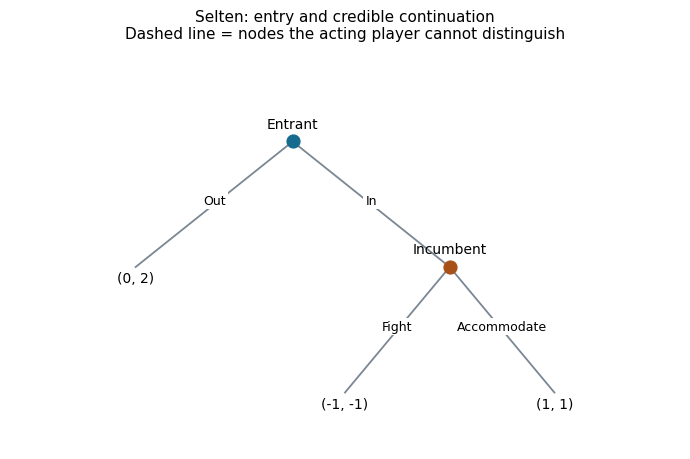

[Editable Mermaid tree](https://github.com/sunshineluyao/gt-tools-demos/blob/main/docs/assets/entry_game.mmd).

The same game can be written in strategic form. The incumbent's strategy specifies what it would do **if** entry occurred, including when that node is not reached.

| Entrant / Incumbent's plan after In | Fight | Accommodate |
|---|---:|---:|
| Out | (0, 2) | (0, 2) |
| In | (−1, −1) | (1, 1) |

**Pure Nash equilibria:** (Out, Fight) and (In, Accommodate).

**Backward induction:** after In, the incumbent compares $u_I(\mathrm{Accommodate})=1$ with $u_I(\mathrm{Fight})=-1$. It accommodates. Anticipating this, the entrant compares 1 with the outside payoff 0 and enters.

$$
\mathrm{SPNE}=(\mathrm{In},\mathrm{Accommodate}).
$$

The separate continuation check is essential: a general Nash solver does not automatically certify subgame perfection.

## 3. Selten: solve the continuation before the initial move

Baseline payoffs are Out $(0,2)$, Fight $(-1,-1)$, and Accommodate $(1,1)$.

| Cue | Backward-induction pseudocode | Mathematical decision |
|---|---|---|
| 🏁 Terminal values | `read payoffs at every leaf` | No terminal outcome may be omitted |
| ← Incumbent | `R ← argmax{fight payoff, accommodate payoff}` | Choose every best response after **In**, including ties |
| ← Entrant | `choose argmax{outside payoff, entry payoff under R}` | Anticipate the credible continuation |
| ✓ Refine | `SPNE ← strategies optimal in every subgame` | Remove Nash profiles supported by a non-credible threat |

The critical distinction is **Nash checks the whole strategy profile; Selten additionally checks the action that would be optimal after every observed history**. The sliders below let you change all payoff terms that determine this example.

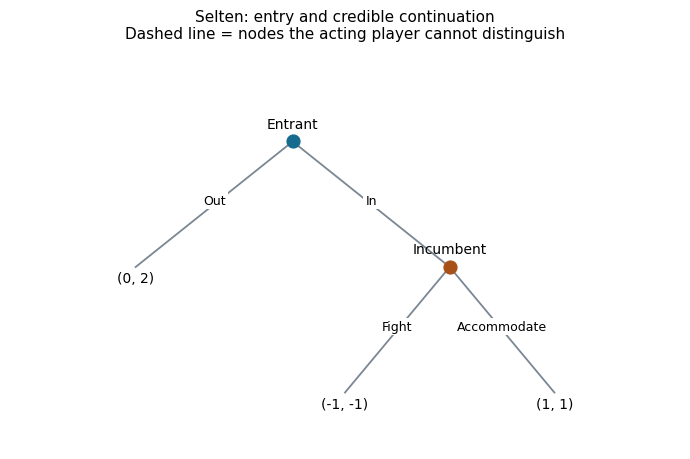

,Entrant,Incumbent after In
0,Out,Fight
1,In,Accommodate


Pure SPNE after the separate continuation check:


,Entrant,Incumbent after In
0,In,Accommodate


In [5]:
def make_entry(fight_payoff=-1, accommodate_payoff=1, entrant_payoff=1):
    """Create Out=(0,2), Fight=(-1,fight_payoff), Accommodate=(entrant_payoff,accommodate_payoff)."""
    game = gb.Game.new_tree(players=["Entrant", "Incumbent"], title="Selten: entry and credible continuation")
    game.append_move(game.root, "Entrant", ["Out", "In"])
    out_node, in_node = list(game.root.children)
    game.append_move(in_node, "Incumbent", ["Fight", "Accommodate"])
    leaves = [out_node, *list(in_node.children)]
    outcomes = [("Out", [0, 2]), ("Fight", [-1, fight_payoff]),
                ("Accommodate", [entrant_payoff, accommodate_payoff])]
    for node, (label, payoffs) in zip(leaves, outcomes):
        game.set_outcome(node, game.add_outcome(label=label, payoffs=payoffs))
    return game

def entry_pure_nash(game):
    """List pure Nash plans, including what the incumbent would do off path."""
    infos = list(game.infosets)
    return [{"Entrant": next(a.label for a in infos[0].actions if eq.as_behavior()[a] == 1),
             "Incumbent after In": next(a.label for a in infos[1].actions if eq.as_behavior()[a] == 1)}
            for eq in gb.nash.enumpure_solve(game).equilibria]

def backward_induction(fight_payoff=-1, accommodate_payoff=1, entrant_payoff=1):
    """Return every pure SPNE, retaining all tied best responses."""
    continuations = [("Fight", -1, fight_payoff), ("Accommodate", entrant_payoff, accommodate_payoff)]
    best_incumbent = max(item[2] for item in continuations)
    return [{"Entrant": choice, "Incumbent after In": response}
            for response, entry_value, incumbent_value in continuations if incumbent_value == best_incumbent
            for choice, value in [("Out", 0), ("In", entry_value)] if value == max(0, entry_value)]

def explore_entry(fight_payoff=-1, accommodate_payoff=1, entrant_payoff=1):
    game = make_entry(fight_payoff, accommodate_payoff, entrant_payoff)
    draw_tree(game)
    display(pd.DataFrame(entry_pure_nash(game)))
    print("Pure SPNE after the separate continuation check:")
    display(pd.DataFrame(backward_induction(fight_payoff, accommodate_payoff, entrant_payoff)))
    game.to_efg(EXPORT / "entry_current.efg")
    return game

entry_game = explore_entry()
entry_game.to_efg(EXPORT / "entry_baseline.efg")
assert backward_induction() == [{"Entrant": "In", "Incumbent after In": "Accommodate"}]

## Saved experiment · a credible threat

The following change has already been executed. Raising the incumbent's Fight payoff to 2 makes Fight better than Accommodate (1). The entrant anticipates −1 from entering and chooses Out. Compare the saved result with the baseline above.

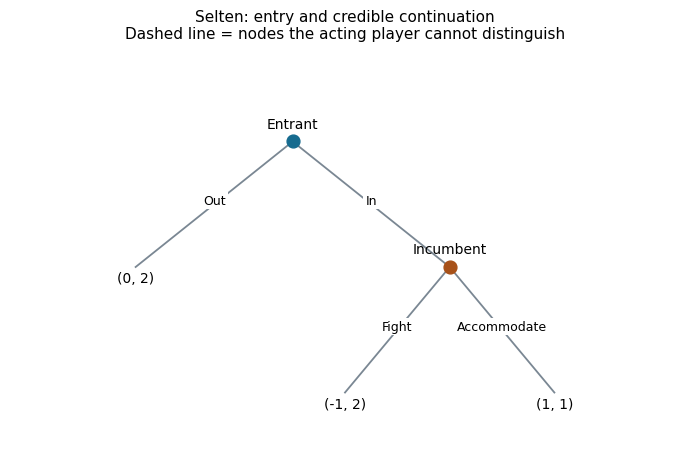

,Entrant,Incumbent after In
0,Out,Fight


Pure SPNE after the separate continuation check:


,Entrant,Incumbent after In
0,Out,Fight


In [6]:
# Raise only the incumbent's payoff from fighting.
credible_threat_game = explore_entry(fight_payoff=2, accommodate_payoff=1, entrant_payoff=1)
credible_threat_game.to_efg(EXPORT / "entry_credible_threat.efg")
assert backward_induction(2, 1, 1) == [{"Entrant": "Out", "Incumbent after In": "Fight"}]

## 4. Change the credibility of the threat
Try increasing the incumbent's Fight payoff above its Accommodate payoff. Then make those payoffs equal. Explain the difference between the entire Nash list and the SPNE list.


In [7]:
# Change one continuation payoff, predict, then rebuild the game.
def payoff_slider(value, description):
    return widgets.IntSlider(value=value, min=-3, max=3, description=description,
                             style={"description_width": "160px"})

fight_slider = payoff_slider(-1, "Fight: incumbent")
accommodate_slider = payoff_slider(1, "Accommodate: incumbent")
entrant_slider = payoff_slider(1, "Accommodate: entrant")
entry_button, entry_output = widgets.Button(description="Rebuild and solve", button_style="primary"), widgets.Output()

def run_entry(_=None):
    with entry_output:
        clear_output(wait=True)
        explore_entry(fight_slider.value, accommodate_slider.value, entrant_slider.value)

entry_button.on_click(run_entry)
display(widgets.VBox([fight_slider, accommodate_slider, entrant_slider, entry_button, entry_output]))

Interactive controls: run this cell in Colab. Saved demonstrations are shown above.

## Game card · private information and information sets

Firm 1's cost is $c_1=1$. Firm 2 privately knows whether its cost is $c_2=1$ (low) or $c_2=3$ (high). The common prior is $p=\Pr(c_2=1)=1/2$. Firms choose simultaneously; a sole entrant earns revenue 4, and two entrants each earn revenue 2. Out pays 0.

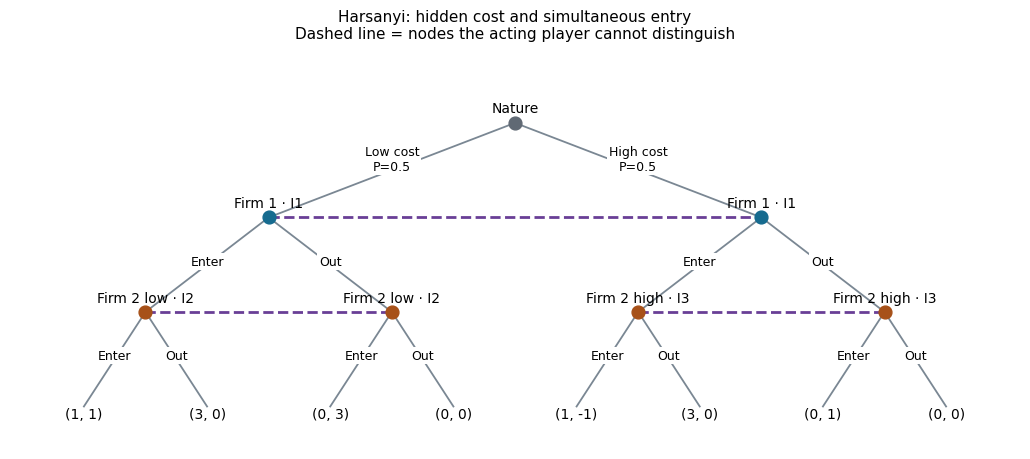

[Editable Mermaid information structure](https://github.com/sunshineluyao/gt-tools-demos/blob/main/docs/assets/bayesian_information_sets.mmd).

- **I1, Firm 1:** its two nodes are linked because it does not know Firm 2's cost.
- **I2, Firm 2 low:** its two low-cost nodes are linked because it does not see Firm 1's action.
- **I3, Firm 2 high:** its two high-cost nodes are linked for the same reason. I2 and I3 remain separate because Firm 2 knows its own cost.

Each type has its own normal-form payoff table. These tables show conditional payoffs; Firm 1 does not observe which table Nature selected.

**Low-cost type**

| Firm 1 / Firm 2 | Enter | Out |
|---|---:|---:|
| Enter | (1, 1) | (3, 0) |
| Out | (0, 3) | (0, 0) |

**High-cost type**

| Firm 1 / Firm 2 | Enter | Out |
|---|---:|---:|
| Enter | (1, −1) | (3, 0) |
| Out | (0, 1) | (0, 0) |

A Bayesian strategy is a complete plan for every type. At the baseline, Firm 2's plan is **Enter if low; Out if high**, written $s_2=(\mathrm{Enter},\mathrm{Out})$. Against that plan,

$$
\mathbb{E}[u_1(\mathrm{Enter},s_2)]
=p(2-c_1)+(1-p)(4-c_1)=3-2p.
$$

At $p=1/2$, entering yields 2 and staying out yields 0. When Firm 1 enters, low-cost Firm 2 earns $2-1=1>0$ by entering; high-cost Firm 2 earns $2-3=-1<0$ by entering and therefore stays out.

$$
\mathrm{BNE}=(\mathrm{Enter};\mathrm{Enter}\text{ if low},\mathrm{Out}\text{ if high}).
$$

Expected baseline payoffs are $(2,1/2)$. A tree is a representation: these linked information sets preserve **simultaneous choice with private costs**, not an observed sequence of actions.

## 5. Harsanyi: make private information explicit

Firm 1 has cost $c_1$. Firm 2 privately knows whether $c_2=1$ (low) or $c_2=c_H$ (high). The common prior is $p=\Pr(c_2=1)$. Both choose Enter or Out **simultaneously**.

| Cue | Type-space pseudocode | Mathematical check |
|---|---|---|
| 🎲 Nature | `draw type t₂ ∈ {low, high} with prior p` | $0<p<1$ keeps both types relevant |
| 🔒 Information | `Firm 1 cannot observe t₂; Firm 2 observes only its own type` | Link indistinguishable nodes in the same information set |
| 🧩 Strategy | `s₂ ← (action if low, action if high)` | A Bayesian strategy is a complete type-contingent plan |
| ✓ Incentives | `test Firm 1 in expectation; test each Firm 2 type conditionally` | $\mathbb E[u_1(s)]\geq\mathbb E[u_1(a_1',s_{-1})]$ and $u_2(s\mid t_2)\geq u_2(a_2',s_{-2}\mid t_2)$ |
| → Report | `show plan and expected payoffs` | Distinguish changed beliefs/payoffs from changed equilibrium actions |

Nature and information sets make uncertainty visible; they do **not** turn this static game into an observed sequence. Move the prior and cost controls below to see which incentive inequalities change.

P(low)=0.50; costs: Firm 1=1, Firm 2=1 or 3


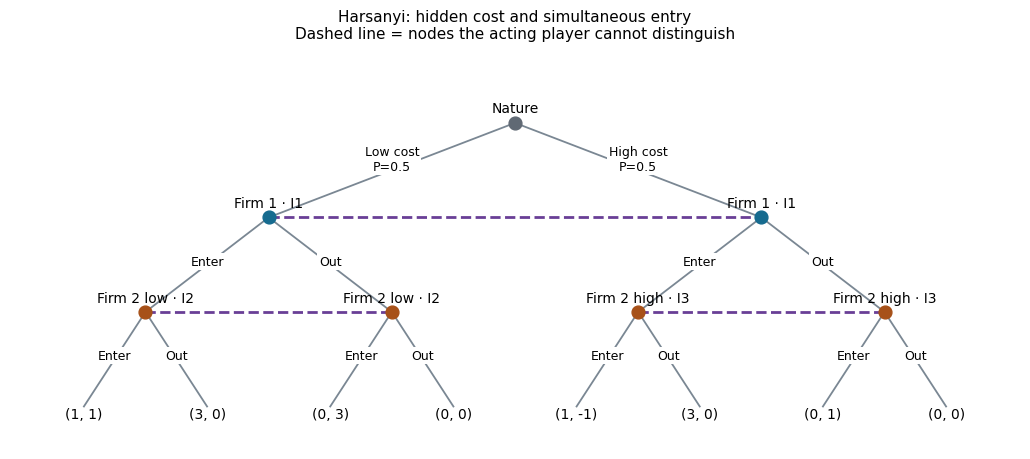

,Firm 1,Firm 2: low,Firm 2: high,Firm 1 expected payoff,Firm 2 expected payoff
0,Enter,Enter,Out,2.0,0.5


✓ Solver plans agree with the independent type-by-type deviation check.


In [8]:
def entry_profit(own_enter, other_enter, cost):
    """Entry earns revenue 4 alone or 2 with a rival, minus own cost; Out earns zero."""
    return (2 if other_enter else 4) - cost if own_enter else 0

def make_bayesian(prior_low=0.5, high_cost=3, firm1_cost=1):
    """Represent a static Bayesian entry game with hidden type and hidden simultaneous action."""
    if not 0 < prior_low < 1:
        raise ValueError("Use a prior strictly between zero and one.")
    game = gb.Game.new_tree(players=["Firm 1", "Firm 2"], title="Harsanyi: hidden cost and simultaneous entry")
    game.append_move(game.root, game.players.chance, ["Low cost", "High cost"])
    game.root.infoset.label = "Nature"
    p = gb.Rational(str(prior_low))
    game.set_chance_probs(game.root.infoset, [p, 1 - p])
    low_node, high_node = list(game.root.children)

    # One information set: Firm 1 cannot observe Firm 2's cost type.
    game.append_move([low_node, high_node], "Firm 1", ["Enter", "Out"])
    low_node.infoset.label = "Firm 1"
    for type_node, cost, label in [(low_node, 1, "Firm 2: low"), (high_node, high_cost, "Firm 2: high")]:
        firm2_nodes = list(type_node.children)
        # Two type-specific sets: Firm 2 knows its type, but not Firm 1's simultaneous action.
        game.append_move(firm2_nodes, "Firm 2", ["Enter", "Out"])
        firm2_nodes[0].infoset.label = label
        for action1, node in enumerate(firm2_nodes):
            for action2, leaf in enumerate(node.children):
                enter1, enter2 = action1 == 0, action2 == 0
                payoffs = [entry_profit(enter1, enter2, firm1_cost), entry_profit(enter2, enter1, cost)]
                game.set_outcome(leaf, game.add_outcome(label=f"{label}: {action1},{action2}", payoffs=payoffs))
    return game

def bayesian_pure_nash(game):
    """Translate Gambit's equilibria into readable type-contingent plans."""
    info = {item.label: item for item in game.infosets if item.player != game.players.chance}
    labels = ["Firm 1", "Firm 2: low", "Firm 2: high"]
    rows = []
    for eq in gb.nash.enumpure_solve(game).equilibria:
        behavior = eq.as_behavior()
        row = {label: next(a.label for a in info[label].actions if behavior[a] == 1) for label in labels}
        row |= {f"{player.label} expected payoff": float(eq.payoff(player)) for player in game.players}
        rows.append(row)
    return rows

def bayesian_deviation_check(prior_low=0.5, high_cost=3, firm1_cost=1):
    """Independently test every pure type-contingent plan."""
    stable = []
    for enter1, low_enter, high_enter in product([True, False], repeat=3):
        plans = [(low_enter, 1, prior_low), (high_enter, high_cost, 1 - prior_low)]
        value1 = sum(weight * entry_profit(enter1, action2, firm1_cost) for action2, _, weight in plans)
        alternative1 = sum(weight * entry_profit(not enter1, action2, firm1_cost) for action2, _, weight in plans)
        type_gains = [entry_profit(not action2, enter1, cost) - entry_profit(action2, enter1, cost)
                      for action2, cost, _ in plans]
        if max(alternative1 - value1, *type_gains) <= 1e-9:
            stable.append(tuple("Enter" if action else "Out" for action in [enter1, low_enter, high_enter]))
    return stable

def explore_bayesian(prior_low=0.5, high_cost=3, firm1_cost=1):
    game = make_bayesian(prior_low, high_cost, firm1_cost)
    print(f"P(low)={prior_low:.2f}; costs: Firm 1={firm1_cost}, Firm 2=1 or {high_cost}")
    draw_tree(game)
    rows = bayesian_pure_nash(game)
    display(pd.DataFrame(rows))
    plans = {(r["Firm 1"], r["Firm 2: low"], r["Firm 2: high"]) for r in rows}
    assert plans == set(bayesian_deviation_check(prior_low, high_cost, firm1_cost))
    print("✓ Solver plans agree with the independent type-by-type deviation check.")
    game.to_efg(EXPORT / "bayesian_current.efg")
    return game

bayesian_game = explore_bayesian()
bayesian_game.to_efg(EXPORT / "bayesian_baseline.efg")
assert bayesian_deviation_check() == [("Enter", "Enter", "Out")]

## Saved experiments · change beliefs, then costs

These examples are also precomputed. With $p=0.8$ and the original costs, equilibrium actions stay the same but Firm 1's expected payoff is $3-2(0.8)=1.4$. Next raise Firm 1's cost to 3; staying Out becomes optimal, while both Firm 2 types enter.

P(low)=0.80; costs: Firm 1=1, Firm 2=1 or 3


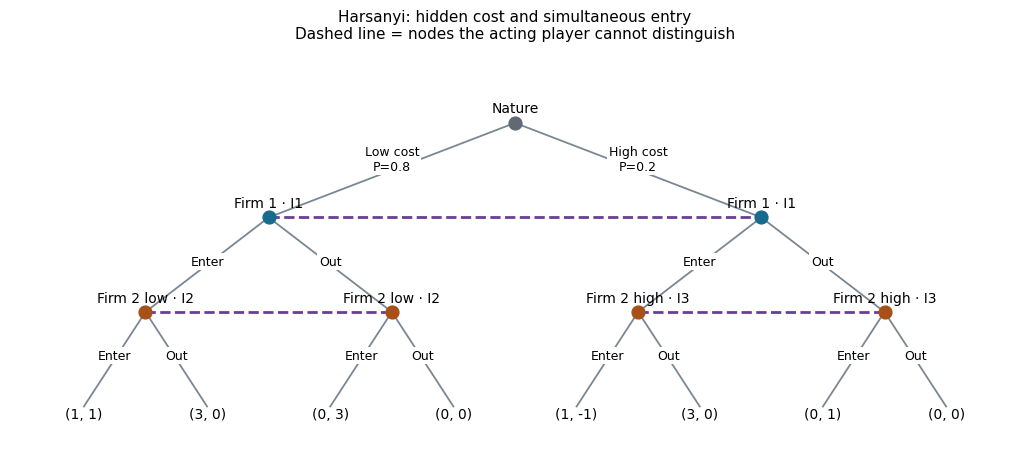

,Firm 1,Firm 2: low,Firm 2: high,Firm 1 expected payoff,Firm 2 expected payoff
0,Enter,Enter,Out,1.4,0.8


✓ Solver plans agree with the independent type-by-type deviation check.
P(low)=0.80; costs: Firm 1=3, Firm 2=1 or 3


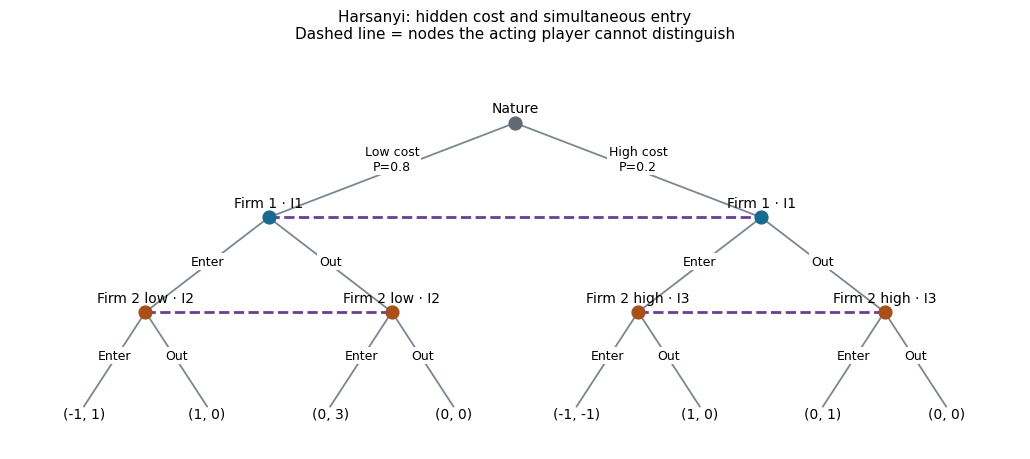

,Firm 1,Firm 2: low,Firm 2: high,Firm 1 expected payoff,Firm 2 expected payoff
0,Out,Enter,Enter,0.0,2.6


✓ Solver plans agree with the independent type-by-type deviation check.


In [9]:
# Change beliefs only: the same pure equilibrium, a different expected payoff.
prior_changed_game = explore_bayesian(prior_low=0.8, high_cost=3, firm1_cost=1)
prior_changed_game.to_efg(EXPORT / "bayesian_prior_08.efg")
assert np.isclose(bayesian_pure_nash(prior_changed_game)[0]["Firm 1 expected payoff"], 1.4)

# Raise Firm 1's cost: now its optimal action and Firm 2's high-type plan change.
high_firm1_cost_game = explore_bayesian(prior_low=0.8, high_cost=3, firm1_cost=3)
high_firm1_cost_game.to_efg(EXPORT / "bayesian_high_firm1_cost.efg")
assert bayesian_deviation_check(0.8, 3, 3) == [("Out", "Enter", "Enter")]

## 6. Change uncertainty and costs
First change only the prior. A payoff or belief can change without changing the equilibrium actions. Next raise Firm 1's cost or change the high type's cost. Check incentives separately for the low and high types.

Every displayed plan is checked against direct expected-payoff inequalities. The prior stays strictly between 0 and 1; zero-probability types require additional care.


In [10]:
# Change beliefs or costs one at a time, then recompute.
prior_slider = widgets.FloatSlider(value=.5, min=.05, max=.95, step=.05, description="P(low cost)")
high_cost_slider = widgets.IntSlider(value=3, min=2, max=5, description="High cost")
firm1_cost_slider = widgets.IntSlider(value=1, min=1, max=3, description="Firm 1 cost")
bayes_button, bayes_output = widgets.Button(description="Rebuild and solve", button_style="primary"), widgets.Output()

def run_bayesian(_=None):
    with bayes_output:
        clear_output(wait=True)
        explore_bayesian(prior_slider.value, high_cost_slider.value, firm1_cost_slider.value)

bayes_button.on_click(run_bayesian)
display(widgets.VBox([prior_slider, high_cost_slider, firm1_cost_slider, bayes_button, bayes_output]))

Interactive controls: run this cell in Colab. Saved demonstrations are shown above.

## 7. Move the same games into the classroom UI
Use the Colab **Files** sidebar to download files from `game_exports/`. No separate model needs to be typed by hand.

1. Open `entry_baseline.efg` in the **Gambit desktop application** using File → Open.
2. Identify the two decision nodes and three payoff pairs. Use **Tools → Equilibrium** to compute profiles. Use **View → Profiles** to inspect them.
3. Compare the pure profiles with the notebook's backward-induction answer. A menu that computes Nash equilibria does not by itself certify subgame perfection.
4. Open `bayesian_baseline.efg`. Locate Nature, Firm 1's linked nodes, and Firm 2's two type-specific information sets. Use **Format → Labels** if information-set labels are hidden.
5. Change a parameter in the notebook, click Rebuild and solve, download `entry_current.efg` or `bayesian_current.efg`, and reopen it in Gambit.

**GTE is a separate graphical web tool** for constructing and analyzing strategic and extensive games. Its [landing page](http://www.gametheoryexplorer.org/) and [builder](http://gte.csc.liv.ac.uk/gte/builder/) are the instructor-supplied links. Its repository documents a legacy Flash GUI, so check access before class. Use the Gambit desktop workflow if the builder does not render; no browser plug-in installation is part of this lesson. The full UI walkthrough is in `docs/Wednesday_UI_Demo.md`.


## 8. Your interdisciplinary explanation
- **Economist:** identify the incentive inequality that changed and interpret entry and welfare.
- **Computer scientist:** explain why an information set, a player label or an axis convention changes the computed problem.
- **Behavioral scientist:** propose one observable departure from the equilibrium benchmark and one way to investigate it.

**Exit ticket:** submit one changed parameter, your predicted effect, the solver output, and a two-sentence explanation. These toy models illustrate the concepts; they do not reproduce a research paper's full experiment. Dynamic games with private information, equilibrium refinements and large-scale learning tools are future topics.


## References and licenses
- Nash (1950), *Equilibrium points in n-person games*. https://doi.org/10.1073/pnas.36.1.48
- Selten (1965), *Spieltheoretische Behandlung eines Oligopolmodells mit Nachfrageträgheit: Teil I*. Zeitschrift für die gesamte Staatswissenschaft, 121, 301–324. https://www.jstor.org/stable/40748884
- Harsanyi (1967), *Games with incomplete information played by “Bayesian” players, I: The basic model*. Management Science, 14(3), 159–182. https://doi.org/10.1287/mnsc.14.3.159
- Savani, R., & Turocy, T. L. (2026). *Gambit: The package for computation in game theory*, version 16.7.0. https://www.gambit-project.org/cite/
- Research use: Gemp, I., Marris, L., & Piliouras, G. (2024). *Approximating Nash Equilibria in Normal-Form Games via Stochastic Optimization*. ICLR 2024. Appendix C.1 compares seven Gambit methods on Blotto games. [Official paper](https://proceedings.iclr.cc/paper_files/paper/2024/file/420678bb4c8251ab30e765bc27c3b047-Paper-Conference.pdf).
- Savani, R., & von Stengel, B. (2015). *Game Theory Explorer – Software for the Applied Game Theorist*. Computational Management Science, 12, 5–33. https://doi.org/10.1007/s10287-014-0206-x
- [PyGambit API](https://gambitproject.readthedocs.io/en/stable/pygambit.html) · [Gambit GUI equilibrium guide](https://gambitproject.readthedocs.io/en/stable/gui.nash.html).

**Gambit/PyGambit: GPL-2.0-or-later. GTE: GPL-3.0.** These are separate projects; installing PyGambit does not install either a desktop GUI or GTE.
